In [25]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


dipole = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/dipole_moments.csv'))
structures = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/structures.csv'))
scalar_coupling_contributions = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/scalar_coupling_contributions.csv'))
magnetic_shielding_tensors = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/magnetic_shielding_tensors.csv'))
mulliken_charges = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/mulliken_charges.csv'))
potential_energy = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/potential_energy.csv'))
samples = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/sample_submission.csv'))
test = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/test.csv'))
train = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/train.csv'))


Let's check feature correlations with scalar_coupling_constant

In [ ]:
train_exp = train.merge(scalar_coupling_contributions, on=['molecule_name', 'atom_index_0', 'atom_index_1'], how='left')
numeric_features = train_exp.select_dtypes(include=np.number).columns
correlations = train_exp[numeric_features].corrwith(train_exp['scalar_coupling_constant'])
correlations = correlations.sort_values(ascending=False)
print(correlations)

scalar_coupling_constant    1.000000
fc                          0.999921
dso                         0.556847
sd                          0.337585
atom_index_0                0.018982
fold                        0.000063
id                         -0.007065
pso                        -0.046271
atom_index_1               -0.218904
dtype: float64


In [3]:
sampled_train = train.sample(n=100000, random_state=50)
train_str = sampled_train.merge(structures, on=['molecule_name'], how='left')
numeric_features = train_str.select_dtypes(include=np.number).columns
correlations = train_str[numeric_features].corrwith(train_str['scalar_coupling_constant'])
correlations = correlations.sort_values(ascending=False)
print(correlations)

scalar_coupling_constant    1.000000
atom_index_0                0.021401
y                           0.003514
x                          -0.000444
id                         -0.001720
z                          -0.002758
atom_index                 -0.008609
atom_index_1               -0.220528
dtype: float64


Let's merge structures to train dataset.

In [4]:
train['atom_index_0'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])

In [5]:
structures['atom_index'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])

In [26]:
first_coord_data = train.merge(structures, left_on=["molecule_name", "atom_index_0"], right_on=["molecule_name", "atom_index"],how="left")
first_coord_data  = first_coord_data .rename(columns={"atom": "atom_0", "x": "x0", "y": "y0", "z": "z0"}).drop("atom_index", axis=1)
train = first_coord_data.merge(structures, left_on=["molecule_name", "atom_index_1"], right_on=["molecule_name", "atom_index"],how="left",).drop("atom_index", axis=1)
train = train.rename(columns={"atom": "atom_1", "x": "x1", "y": "y1", "z": "z1"})
train.head()

,id,molecule_name,atom_index_0,atom_index_1,type,scalar_coupling_constant,atom_0,x0,y0,z0,atom_1,x1,y1,z1
0,0,dsgdb9nsd_000001,1,0,1JHC,84.8076,H,0.002150,-0.006031,0.001976,C,-0.012698,1.085804,0.008001
1,1,dsgdb9nsd_000001,1,2,2JHH,-11.2570,H,0.002150,-0.006031,0.001976,H,1.011731,1.463751,0.000277
2,2,dsgdb9nsd_000001,1,3,2JHH,-11.2548,H,0.002150,-0.006031,0.001976,H,-0.540815,1.447527,-0.876644
3,3,dsgdb9nsd_000001,1,4,2JHH,-11.2543,H,0.002150,-0.006031,0.001976,H,-0.523814,1.437933,0.906397
4,4,dsgdb9nsd_000001,2,0,1JHC,84.8074,H,1.011731,1.463751,0.000277,C,-0.012698,1.085804,0.008001


In [27]:
train["dist"] = np.sqrt((train["x1"] - train["x0"]) ** 2+ (train["y1"] - train["y0"]) ** 2 + (train["z1"] - train["z0"]) ** 2)
# Inverse Distances (Coulomb & VdW approximations)
train["inv_dist"] = 1.0 / train["dist"]
train["inv_dist2"] = 1.0 / (train["dist"] ** 2)
train["inv_dist3"] = 1.0 / (train["dist"] ** 3)
train["inv_dist6"] = 1.0 / (train["dist"] ** 6)  # Van der Waals power component

electronegativity = {"H": 2.20, "C": 2.55, "N": 3.04, "O": 3.44, "F": 3.98}
vdw_radius = {
    "H": 1.10,
    "C": 1.70,
    "N": 1.55,
    "O": 1.52,
    "F": 1.47,
}  # in Angstroms

train["en_0"] = train["atom_0"].map(electronegativity)
train["en_1"] = train["atom_1"].map(electronegativity)
train["en_diff"] = np.abs(train["en_0"] - train["en_1"])

train["vdw_0"] = train["atom_0"].map(vdw_radius)
train["vdw_1"] = train["atom_1"].map(vdw_radius)
train["vdw_sum"] = train["vdw_0"] + train["vdw_1"]

train["vdw_dist_ratio"] = train["dist"] / train["vdw_sum"]

In [28]:
train.head()

,id,molecule_name,atom_index_0,atom_index_1,type,scalar_coupling_constant,atom_0,x0,y0,z0,...,inv_dist2,inv_dist3,inv_dist6,en_0,en_1,en_diff,vdw_0,vdw_1,vdw_sum,vdw_dist_ratio
0,0,dsgdb9nsd_000001,1,0,1JHC,84.8076,H,0.002150,-0.006031,0.001976,...,0.838672,0.768048,0.589897,2.2,2.55,0.35,1.1,1.7,2.8,0.389983
1,1,dsgdb9nsd_000001,1,2,2JHH,-11.2570,H,0.002150,-0.006031,0.001976,...,0.314513,0.176384,0.031111,2.2,2.20,0.00,1.1,1.1,2.2,0.810509
2,2,dsgdb9nsd_000001,1,3,2JHH,-11.2548,H,0.002150,-0.006031,0.001976,...,0.314503,0.176375,0.031108,2.2,2.20,0.00,1.1,1.1,2.2,0.810522
3,3,dsgdb9nsd_000001,1,4,2JHH,-11.2543,H,0.002150,-0.006031,0.001976,...,0.314500,0.176373,0.031107,2.2,2.20,0.00,1.1,1.1,2.2,0.810526
4,4,dsgdb9nsd_000001,2,0,1JHC,84.8074,H,1.011731,1.463751,0.000277,...,0.838674,0.768051,0.589902,2.2,2.55,0.35,1.1,1.7,2.8,0.389983


In [29]:
train.shape

(4659076, 26)

In [30]:
from sklearn.model_selection import GroupKFold
splits=GroupKFold(n_splits=5)
train['fold']=-999
for fold, (train_idx, val_idx) in enumerate(splits.split(train, groups=train['molecule_name'])):
    train.loc[val_idx, 'fold'] = fold

In [31]:
train_fold = train[train['fold'] != 0].copy()
val_fold = train[train['fold'] == 0].copy()

In [32]:
features = [ "x0","y0","z0","x1", "y1", "z1", "dist","inv_dist","inv_dist2", "inv_dist3", "inv_dist6",
             "en_0","en_1","en_diff","vdw_0", "vdw_1","vdw_sum", "vdw_dist_ratio"]
target = "scalar_coupling_constant"

x_train = train_fold[features]
y_train = train_fold[target]
x_val = val_fold[features]
y_val = val_fold[target]

In [14]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=50)
model.fit(x_train, y_train)

y_pred = model.predict(x_   val)
mae = mean_absolute_error(y_val, y_pred)
print(f"Validation MAE: {mae:.4f}")
log_mae = np.log(mae)
print(f"Validation log MAE: {log_mae:.4f}")

Validation MAE: 2.4644
Validation log MAE: 0.9019


In [20]:
import numpy as np
from sklearn.metrics import mean_absolute_error

x_val_df = x_val.copy()
x_val_df["pred"] = y_pred
x_val_df["scalar_coupling_constant"] = y_val
x_val_df["type"] = train.loc[x_val.index, "type"]

def compute_group_log_mae(
    df, target_col="scalar_coupling_constant", pred_col="pred"
):
    type_log_maes = []
    print("Competition Group Log MAE Breakdown")

    for ctype, group in df.groupby("type"):
        type_mae = mean_absolute_error(group[target_col], group[pred_col])
        type_log_mae = np.log(type_mae)
        type_log_maes.append(type_log_mae)

        print(f"Type {ctype:} | MAE: {type_mae:.4f} | Log MAE: {type_log_mae:.4f}")

    overall_score = np.mean(type_log_maes)
    print(f"\nFinal Competition Group Log MAE: {overall_score:.4f}")
    return overall_score

group_log_mae = compute_group_log_mae(x_val_df)

--- Competition Group Log MAE Breakdown ---
Type 1JHC | MAE: 4.9429 | Log MAE: 1.5980
Type 1JHN | MAE: 2.7729 | Log MAE: 1.0199
Type 2JHC | MAE: 2.4704 | Log MAE: 0.9044
Type 2JHH | MAE: 1.3116 | Log MAE: 0.2712
Type 2JHN | MAE: 2.4430 | Log MAE: 0.8932
Type 3JHC | MAE: 1.9971 | Log MAE: 0.6917
Type 3JHH | MAE: 1.8358 | Log MAE: 0.6075
Type 3JHN | MAE: 0.8958 | Log MAE: -0.1100

Final Competition Group Log MAE: 0.7345


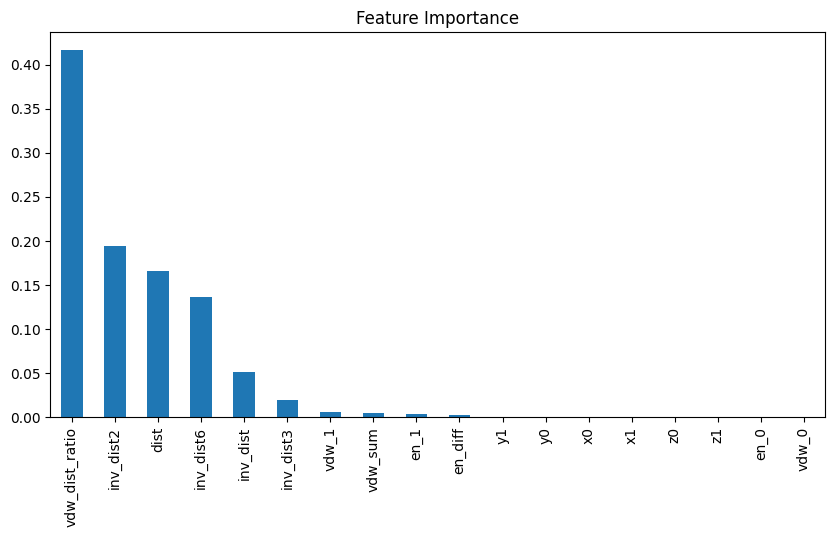

In [16]:
feature_importances = pd.Series(model.feature_importances_, index=features)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5), title="Feature Importance")
plt.show()

In [41]:
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from wandb.integration.xgboost import WandbCallback
import wandb

wandb.init(
    project="dl_assignment-1",
    name="xgb-baseline-experiment",
    config={"learning_rate": 0.1, "max_depth": 6, "n_estimators": 300}
)

model = XGBRegressor( n_estimators=300, learning_rate=0.1,max_depth=6,subsample=0.8,random_state=50,eval_metric=["mae", "rmse"],callbacks=[WandbCallback(log_feature_importance=True)])

model.fit(x_train,y_train, eval_set=[(x_train, y_train), (x_val, y_val)], verbose=10)

y_pred = model.predict(x_val)
mae = mean_absolute_error(y_val, y_pred)

x_val_df = x_val.copy()
x_val_df["pred"] = y_pred
x_val_df["scalar_coupling_constant"] = y_val
x_val_df["type"] = train.loc[x_val.index, "type"] 

type_log_maes = []
print("Per-Type Validation Breakdown")
for ctype, group in x_val_df.groupby("type"):
    group_mae = mean_absolute_error(
        group["scalar_coupling_constant"], group["pred"]
    )
    group_log_mae = np.log(group_mae)
    type_log_maes.append(group_log_mae)

    wandb.log({f"mae_{ctype}": group_mae, f"log_mae_{ctype}": group_log_mae})
    print(f"Type {ctype:<5} | MAE: {group_mae:.4f} | Log MAE: {group_log_mae:.4f}")

overall_group_log_mae = np.mean(type_log_maes)

wandb.log({"final_val_mae": mae, "group_log_mae": overall_group_log_mae})
wandb.finish()

print(f"\nOverall Group Log MAE: {overall_group_log_mae:.4f}")

[0]	validation_0-mae:22.27148	validation_0-rmse:31.49298	validation_1-mae:22.27049	validation_1-rmse:31.50417
[10]	validation_0-mae:8.13209	validation_0-rmse:11.65353	validation_1-mae:8.13422	validation_1-rmse:11.65639
[20]	validation_0-mae:3.79560	validation_0-rmse:5.59295	validation_1-mae:3.79638	validation_1-rmse:5.59418
[30]	validation_0-mae:2.74992	validation_0-rmse:4.25794	validation_1-mae:2.74675	validation_1-rmse:4.25977
[40]	validation_0-mae:2.56177	validation_0-rmse:4.03575	validation_1-mae:2.55780	validation_1-rmse:4.03804
[50]	validation_0-mae:2.51312	validation_0-rmse:3.97643	validation_1-mae:2.50950	validation_1-rmse:3.97920
[60]	validation_0-mae:2.49219	validation_0-rmse:3.94911	validation_1-mae:2.48893	validation_1-rmse:3.95247
[70]	validation_0-mae:2.47771	validation_0-rmse:3.92699	validation_1-mae:2.47454	validation_1-rmse:3.93042
[80]	validation_0-mae:2.46317	validation_0-rmse:3.91081	validation_1-mae:2.46035	validation_1-rmse:3.91507
[90]	validation_0-mae:2.44977	va

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇█
final_val_mae,▁
group_log_mae,▁
log_mae_1JHC,▁
log_mae_1JHN,▁
log_mae_2JHC,▁
log_mae_2JHH,▁
log_mae_2JHN,▁
log_mae_3JHC,▁
log_mae_3JHH,▁
+13,...



Overall Group Log MAE: 0.6906


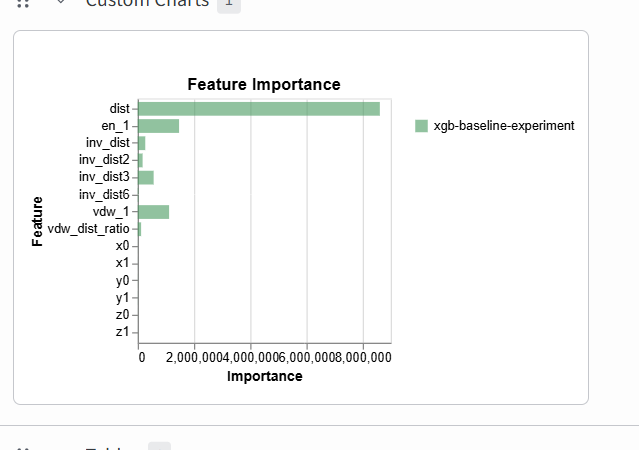

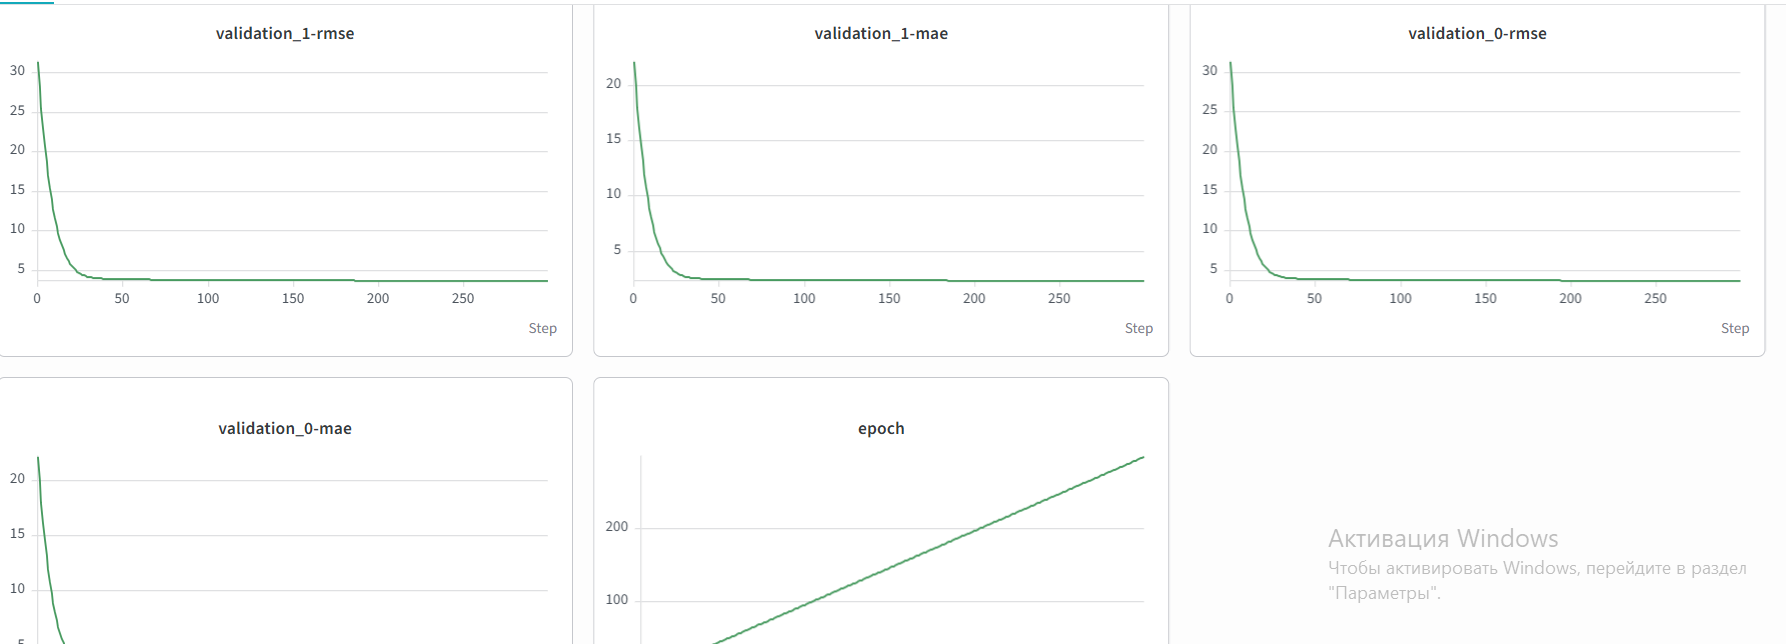

In [43]:
features = ["atom_0","atom_1", "x0","y0","z0","x1", "y1", "z1", "dist","inv_dist","inv_dist2", "inv_dist3", "inv_dist6",
             "en_0","en_1","en_diff","vdw_0", "vdw_1","vdw_sum", "vdw_dist_ratio"]
x_train = train_fold[features].copy()
x_val = val_fold[features].copy()

In [44]:
from sklearn.preprocessing import LabelEncoder

for col in ["atom_0", "atom_1"]:
    if col in train.columns and train[col].dtype == "object":
        le = LabelEncoder()
        x_train[col] = le.fit_transform(x_train[col])
        x_val[col] = le.transform(x_val[col])

In [46]:
wandb.init(
    project="dl_assignment-1",
    name="xgb-tuned-hyperparams",
    config={ "n_estimators": 800,"learning_rate": 0.05, "max_depth": 9,"subsample": 0.8}
)

model_tuned = XGBRegressor( n_estimators=800, learning_rate=0.05, max_depth=9,subsample=0.8,random_state=50,eval_metric=["mae", "rmse"],callbacks=[WandbCallback(log_feature_importance=True)])
model_tuned.fit(x_train,y_train,eval_set=[(x_train, y_train), (x_val, y_val)],verbose=30)

y_pred_tuned = model_tuned.predict(x_val)
mae_tuned = mean_absolute_error(y_val, y_pred_tuned)

x_val_df = x_val.copy()
x_val_df["pred"] = y_pred_tuned
x_val_df["scalar_coupling_constant"] = y_val
x_val_df["type"] = train.loc[x_val.index, "type"]

type_log_maes = []
for ctype, group in x_val_df.groupby("type"):
    group_mae = mean_absolute_error(
        group["scalar_coupling_constant"], group["pred"]
    )
    group_log_mae = np.log(group_mae)
    type_log_maes.append(group_log_mae)

    wandb.log( {f"tuned_mae_{ctype}": group_mae, f"tuned_log_mae_{ctype}": group_log_mae})
    print(f"Type {ctype:<5} | MAE: {group_mae:.4f} | Log MAE: {group_log_mae:.4f}")

group_log_mae_tuned = np.mean(type_log_maes)

wandb.log({"final_val_mae": mae_tuned, "group_log_mae": group_log_mae_tuned})
wandb.finish()

print(f"\nTuned Overall Group Log MAE: {group_log_mae_tuned:.4f}")

[0]	validation_0-mae:23.49613	validation_0-rmse:33.20951	validation_1-mae:23.49466	validation_1-rmse:33.22137
[30]	validation_0-mae:5.60127	validation_0-rmse:8.09263	validation_1-mae:5.60309	validation_1-rmse:8.09626
[60]	validation_0-mae:2.65372	validation_0-rmse:4.11747	validation_1-mae:2.65540	validation_1-rmse:4.13101
[90]	validation_0-mae:2.37736	validation_0-rmse:3.77436	validation_1-mae:2.38115	validation_1-rmse:3.79528
[120]	validation_0-mae:2.32883	validation_0-rmse:3.70355	validation_1-mae:2.33583	validation_1-rmse:3.73140
[150]	validation_0-mae:2.29750	validation_0-rmse:3.65268	validation_1-mae:2.30803	validation_1-rmse:3.68946
[180]	validation_0-mae:2.27512	validation_0-rmse:3.62225	validation_1-mae:2.28846	validation_1-rmse:3.66500
[210]	validation_0-mae:2.25706	validation_0-rmse:3.59786	validation_1-mae:2.27284	validation_1-rmse:3.64578
[240]	validation_0-mae:2.24025	validation_0-rmse:3.57306	validation_1-mae:2.25855	validation_1-rmse:3.62697
[270]	validation_0-mae:2.2248

epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇██
final_val_mae,▁
group_log_mae,▁
tuned_log_mae_1JHC,▁
tuned_log_mae_1JHN,▁
tuned_log_mae_2JHC,▁
tuned_log_mae_2JHH,▁
tuned_log_mae_2JHN,▁
tuned_log_mae_3JHC,▁
tuned_log_mae_3JHH,▁
+13,...



Tuned Overall Group Log MAE: 0.5748


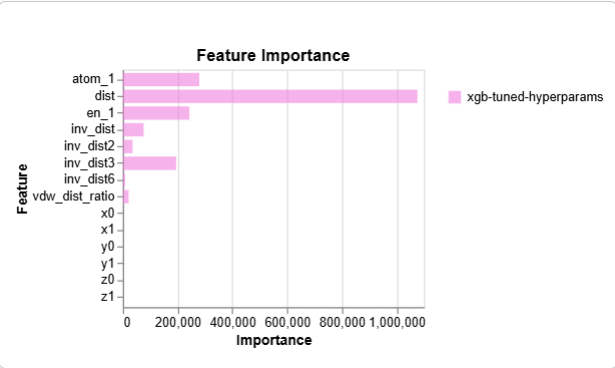

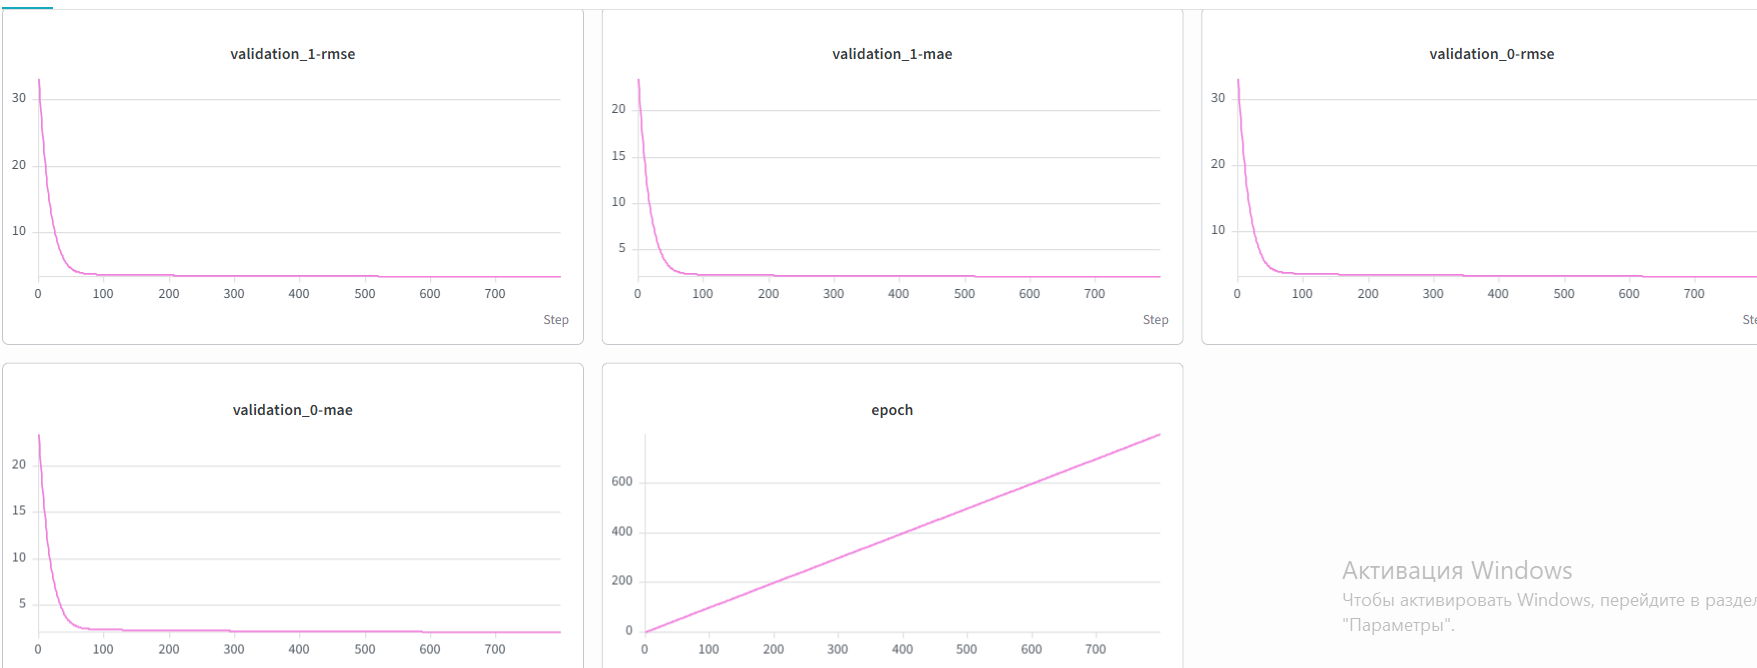

In [64]:
test_raw = pd.read_csv("https://www.kaggle.com/datasets/annaakhlamova/test-manual.csv")
first_coord_test = test_raw.merge(structures,left_on=["molecule_name", "atom_index_0"],right_on=["molecule_name", "atom_index"],how="left").rename(columns={"atom": "atom_0", "x": "x0", "y": "y0", "z": "z0"})
test_df = first_coord_test.merge(structures,left_on=["molecule_name", "atom_index_1"],right_on=["molecule_name", "atom_index"],how="left").rename(columns={"atom": "atom_1", "x": "x1", "y": "y1", "z": "z1"})
test_df["dist"] = np.sqrt((test_df["x1"] - test_df["x0"]) ** 2 + (test_df["y1"] - test_df["y0"]) ** 2 + (test_df["z1"] - test_df["z0"]) ** 2)
test_df["inv_dist"] = 1.0 / test_df["dist"]
test_df["inv_dist2"] = 1.0 / (test_df["dist"] ** 2)
test_df["inv_dist3"] = 1.0 / (test_df["dist"] ** 3)
test_df["inv_dist6"] = 1.0 / (test_df["dist"] ** 6)

test_df["en_0"] = test_df["atom_0"].map(electronegativity)
test_df["en_1"] = test_df["atom_1"].map(electronegativity)
test_df["en_diff"] = np.abs(test_df["en_0"] - test_df["en_1"])
test_df["vdw_0"] = test_df["atom_0"].map(vdw_radius)
test_df["vdw_1"] = test_df["atom_1"].map(vdw_radius)
test_df["vdw_sum"] = test_df["vdw_0"] + test_df["vdw_1"]
test_df["vdw_dist_ratio"] = test_df["dist"] / test_df["vdw_sum"]

for col in ["atom_0", "atom_1"]:
  if col in test_df.columns and test_df[col].dtype == "object":
    test_df[col] = le.transform(test_df[col])
x_test = test_df[features].copy()

In [65]:
test_df["scalar_coupling_constant"] = model_tuned.predict(x_test)
submission = test_df[["id", "scalar_coupling_constant"]]
submission.to_csv("submission.csv", index=False)
submission.head()

,id,scalar_coupling_constant
0,4659076,0.610211
1,4659077,198.217804
2,4659078,1.450453
3,4659079,197.109009
4,4659080,0.486893


In [71]:
test_raw.shape

(2505190, 5)

In [79]:
!kaggle competitions submit -c champs-scalar-coupling -f submission.csv -m "xgboost"

100%|██████████████████████████████████████| 23.9M/23.9M [00:00<00:00, 40.9MB/s]
Successfully submitted to Predicting Molecular Properties